In [460]:
import sys
import os

src_path = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(src_path)

In [461]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from data_processing import signal_processing
import importlib
from plotting import rsp_plot

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.3


In [462]:
importlib.reload(rsp_plot)

<module 'plotting.rsp_plot' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\plotting\\rsp_plot.py'>

In [463]:
# subj11 bully signal
path = r'C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\TestData\subj11-250227-071832'
subj_11 = tdt.read_block(path)

Found Synapse note file: C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\TestData\subj11-250227-071832\Notes.txt
read from t=0s to t=343.94s


#### Taking attributes from Resp stream - signal and sampling rate

In [464]:
subj_11_stream = subj_11.streams['Resp']
subj_11_rsp = subj_11_stream.data
subj_11_fs = subj_11_stream.fs
subj_11_st = subj_11_stream.start_time

subj_11_size = subj_11_rsp.shape[0]

In [465]:
subj_11_rsp_df = rsp_plot.Rsp_Kit(
    resp_data=subj_11_rsp,
    fs=subj_11_fs,
    start_time=subj_11_st,
    size=subj_11_size,
    end_time=None,
)

In [466]:
subj_11_rsp_df.df.head()

,Timestamps,Respiration Value,Behavioral Event,Peaks
0,0.000000,-0.023053,None,-0.023053
1,0.003277,-0.023354,None,-0.023354
2,0.006554,-0.023264,None,NaN
3,0.009830,-0.022772,None,NaN
4,0.013107,-0.021903,None,NaN


C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\plotting\rsp_plot.py:333: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


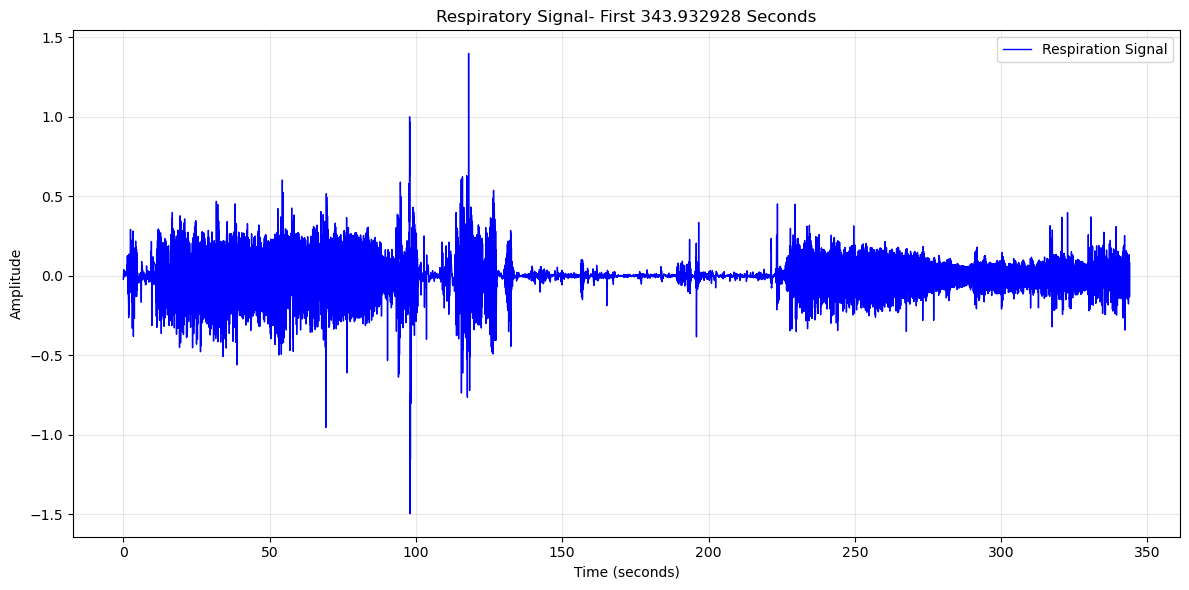

In [467]:
subj_11_rsp_df.plot(duration=subj_11_size / subj_11_fs)

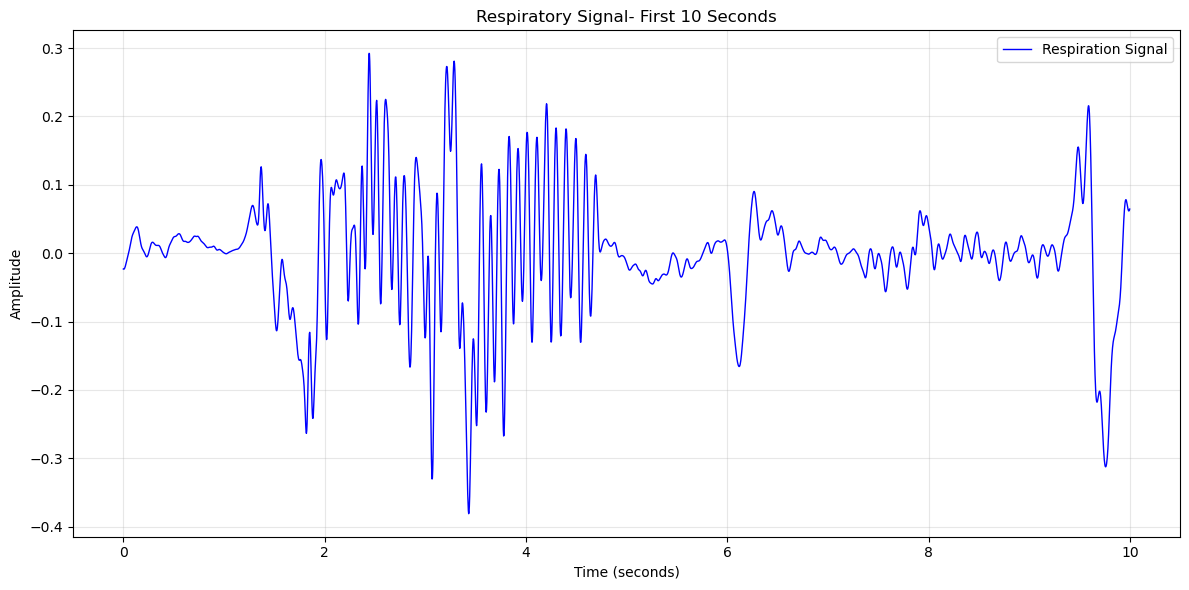

In [468]:
subj_11_rsp_df.plot()

#### Flatline or Likely Signal Loss %

In [469]:
nk.signal_flatline(subj_11_rsp, threshold=1e-2)

0.36896913109756097

#### Finding where loss signal is.
#### Sampling Rate = 2000Hz
#### Window Size: 500 = .25 sec, 1000 = .5 sec

In [470]:
def detect_signal_loss(signal, threshold=1e-2, window=500):
    """
    Detect flatline signal regions using a sliding window.
    
    Args:
        signal (np.array): 1D array of signal values.
        threshold (float): Smallest allowable change between consecutive points.
        window (int): Number of samples over which to check for flatness.
    
    Returns:
        np.array: Boolean array where True means the signal is considered "lost".
    """
    diffs = np.abs(np.diff(signal, prepend=signal[0]))  # prepend to preserve size
    flat = diffs < threshold # if the difference between consecutive points is less than threshold
    # of loss in 
    loss_mask = np.convolve(flat, np.ones(window), mode='same') >= window # convolve - counts # of trues in sliding windo | >= window - checks if # of trues in sliding window are >= window size 
    return loss_mask

In [471]:
loss_signal = detect_signal_loss(subj_11_rsp, threshold=1e-2, window=500)
# Detect flatline regions in the filtered signal

In [472]:
loss_indices = np.where(loss_signal)[0]
print(len(loss_indices))

24116


#### Bandpass Filter - Keeps signal between 1.0-8.0 Hz

In [473]:
'''
Bandpass filter: alters frequency content of the signal, removes
low frequency drift and high frequency noise
'''
# NeuroKit2 Butterworth Bandpass Filter
subj_11_rsp = nk.signal_filter(
    subj_11_rsp,  # Input signal
    lowcut=1.0,   # Low cutoff frequency (Hz)
    highcut=8.0,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=subj_11_fs,  # Sampling rate
    order=2  # Filter order
)


### Option 1 - Interpolate - Short gaps of missing Data

In [474]:
# Assume 'signal' is your respiratory data and 'loss_mask' is from the previous step
signal_with_nans = subj_11_rsp.copy()
signal_with_nans[loss_signal] = np.nan

# Interpolate missing values
linear_interpolated = nk.signal_interpolate(signal_with_nans, method="linear")
cubic_interpolated = nk.signal_interpolate(signal_with_nans, method="cubic") #  Can overshoot if the signal is noisy or irregular—especially near gaps.
akima_interpolated = nk.signal_interpolate(signal_with_nans, method="akima") #  Akima interpolation - safter than cubic interpolation, but it can still produce oscillations in some cases.
monotone_cubic_interpolated = nk.signal_interpolate(signal_with_nans, method="monotone_cubic") #  Monotone cubic interpolation - best for preventing overshooting, but can flatten subtle features, small inflection points or brief pauses.


#### Looking at loss signal still left

In [475]:
c_percent = nk.signal_flatline(cubic_interpolated, threshold=1e-2)
ak_percentd = nk.signal_flatline(akima_interpolated, threshold=1e-2)
m_percent = nk.signal_flatline(monotone_cubic_interpolated, threshold=1e-2)

print(f'Cubic interpolation flatline percentage: {c_percent:.2%}')
print(f'Akima interpolation flatline percentage: {ak_percentd:.2%}')
print(f'Monotone cubic interpolation flatline percentage: {m_percent:.2%}')

Cubic interpolation flatline percentage: 34.71%
Akima interpolation flatline percentage: 35.60%
Monotone cubic interpolation flatline percentage: 35.83%


In [476]:
cub_loss_signal = detect_signal_loss(cubic_interpolated, threshold=1e-2, window=500)
ak_loss_signal = detect_signal_loss(akima_interpolated, threshold=1e-2, window=500)
m_loss_signal = detect_signal_loss(monotone_cubic_interpolated, threshold=1e-2, window=500)
# Detect flatline regions in the filtered signal

cub_loss_indices = np.where(loss_signal)[0]
ak_loss_indices = np.where(ak_loss_signal)[0]
m_loss_indices = np.where(m_loss_signal)[0]

print(len(cub_loss_indices))
print(len(ak_loss_indices))
print(len(m_loss_indices))

24116
34366
34366


In [477]:
cub_rsp_df = rsp_plot.Rsp_Kit(
    resp_data=cubic_interpolated,
    fs=subj_11_fs,
    start_time=subj_11_st,
    size=subj_11_size,
    end_time=None,
)
ak_rsp_df = rsp_plot.Rsp_Kit(
    resp_data=akima_interpolated,
    fs=subj_11_fs,
    start_time=subj_11_st,
    size=subj_11_size,
    end_time=None,
)
m_rsp_df = rsp_plot.Rsp_Kit(
    resp_data=monotone_cubic_interpolated,
    fs=subj_11_fs,
    start_time=subj_11_st,
    size=subj_11_size,
    end_time=None,
)

### Cubic Interpolation Plots

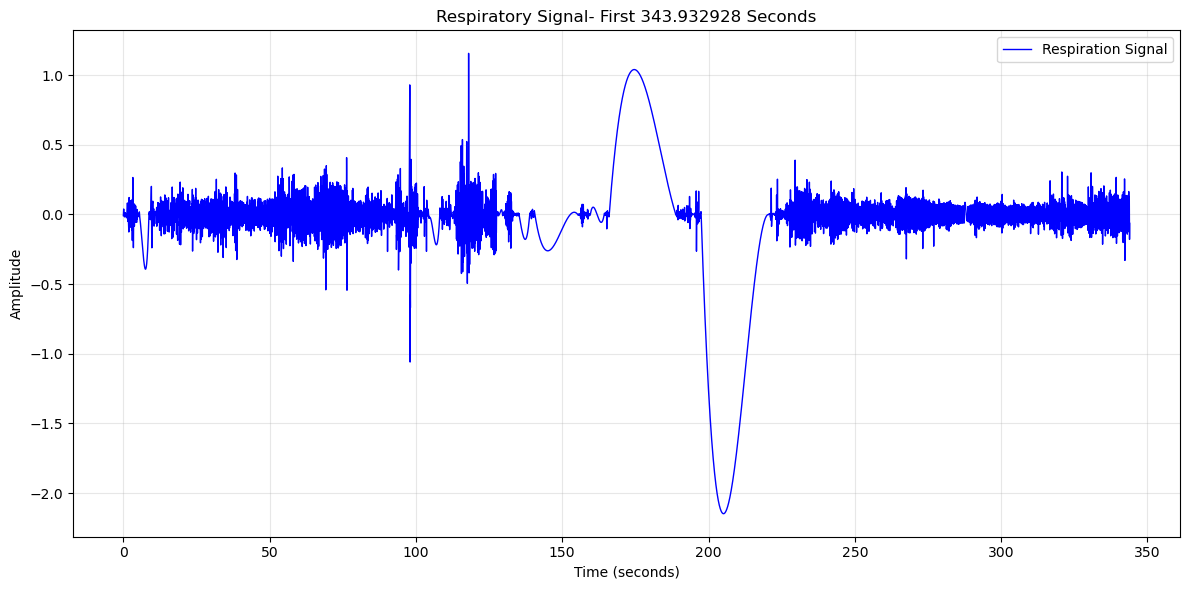

In [478]:
cub_rsp_df.plot(duration=subj_11_size / subj_11_fs)

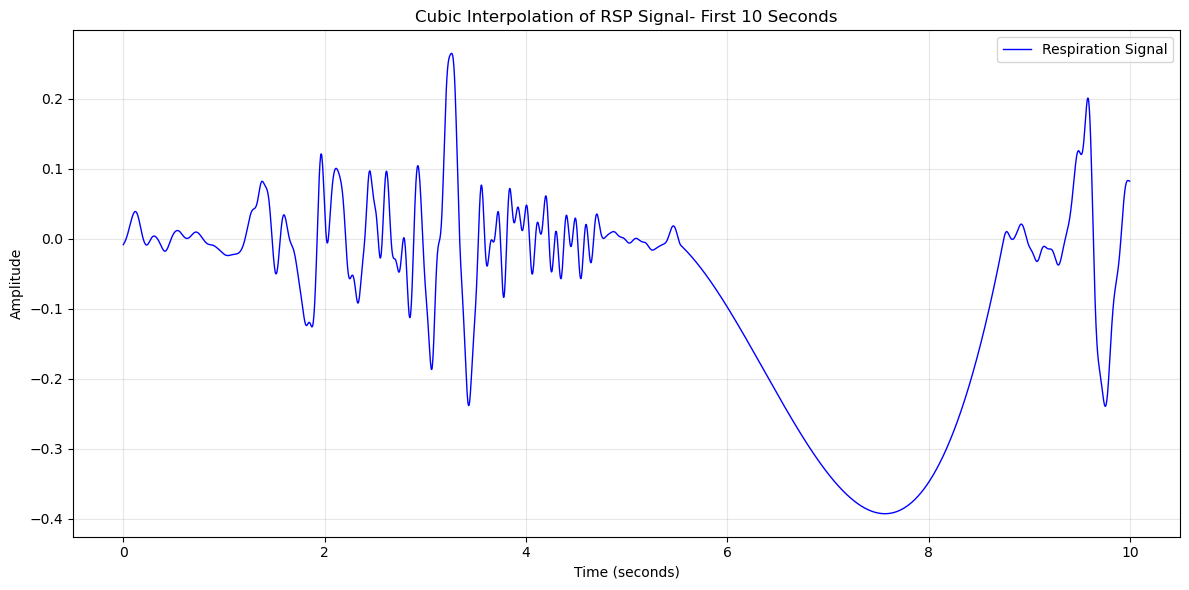

In [479]:
cub_rsp_df.plot(title="Cubic Interpolation of RSP Signal")

### Akima Interpolation Plots

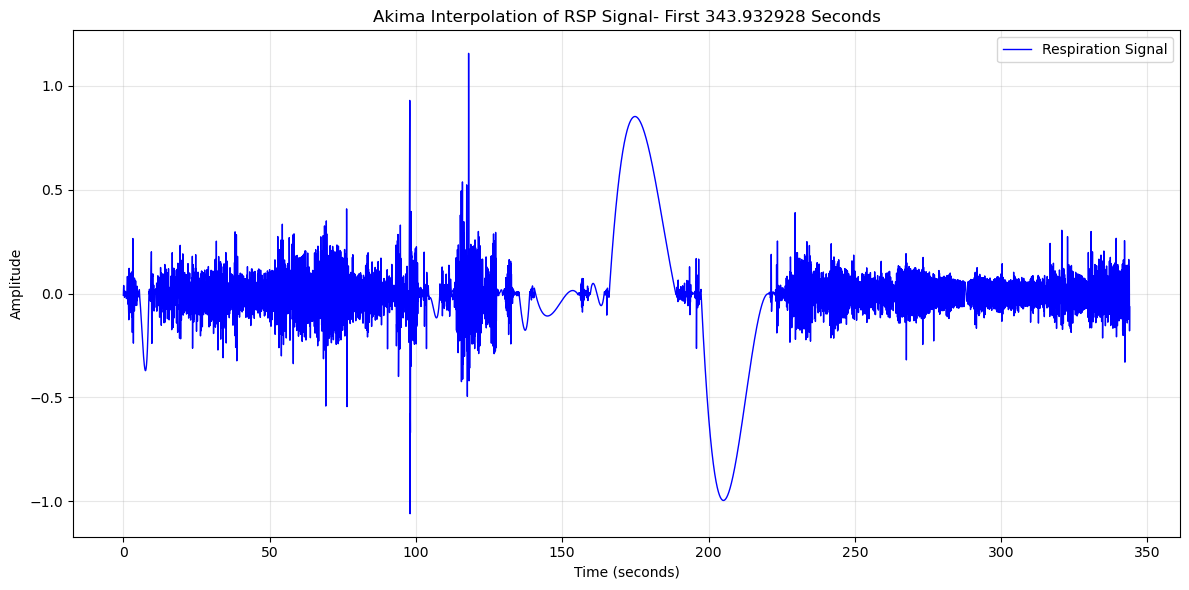

In [480]:
ak_rsp_df.plot(title="Akima Interpolation of RSP Signal", duration=subj_11_size / subj_11_fs)

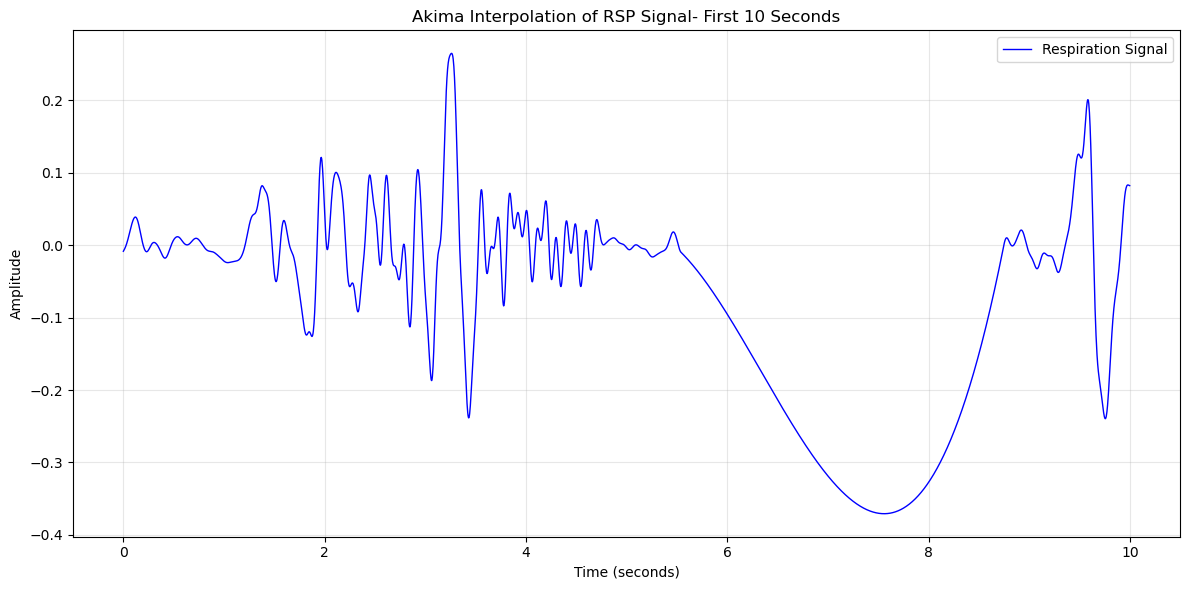

In [481]:
ak_rsp_df.plot(title="Akima Interpolation of RSP Signal")

### Monotone Cubic Plots

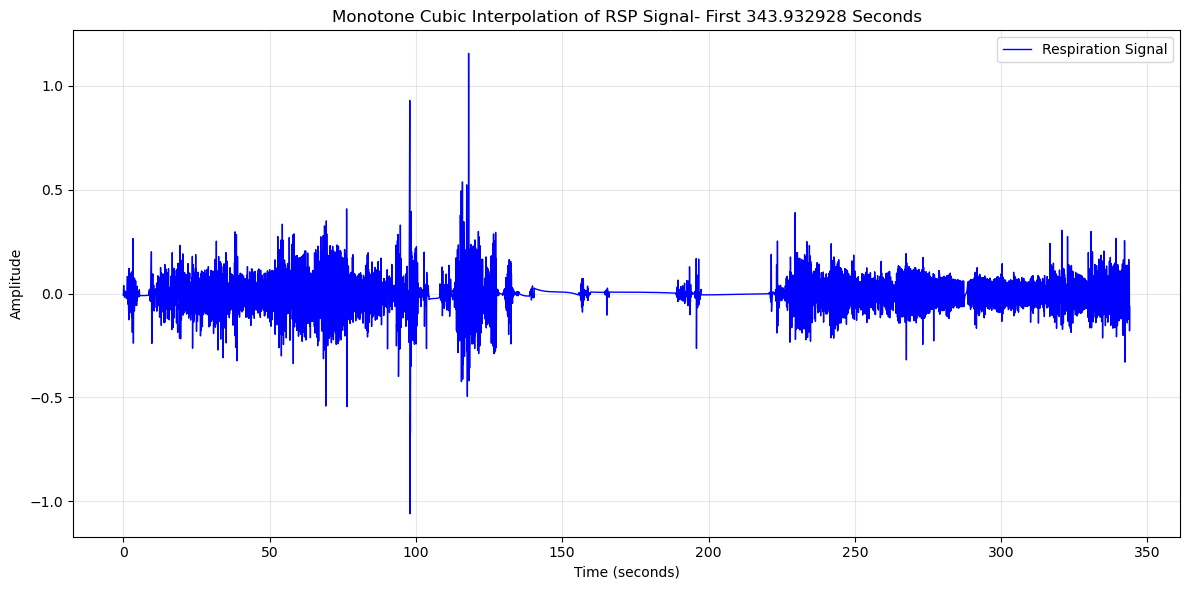

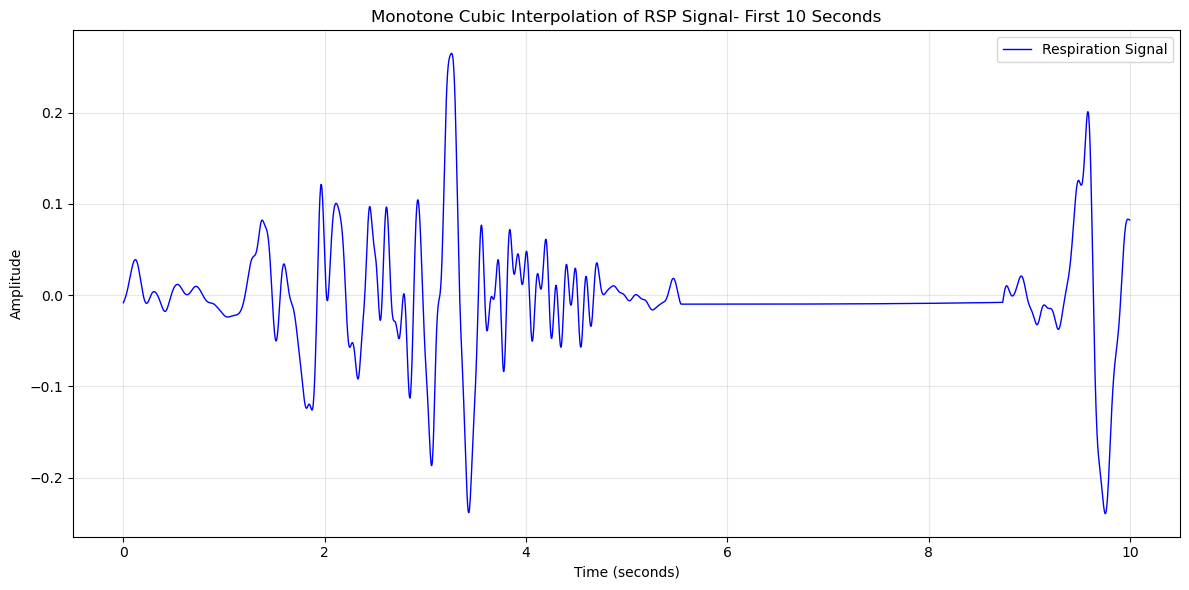

In [482]:
m_rsp_df.plot(title="Monotone Cubic Interpolation of RSP Signal", duration=subj_11_size / subj_11_fs)
m_rsp_df.plot(title="Monotone Cubic Interpolation of RSP Signal")